# OWID COVID: pre-EMM walkthrough

This notebook contains full code and saved executed tables/figures. Use Kernel → Restart Kernel and Run All Cells to reproduce. Local file: `F:/TUeclass/projects/track3_owid/notebooks/owid_pre_emm_walkthrough_en.ipynb`; JupyterLab: `notebooks → owid_pre_emm_walkthrough_en.ipynb`.

Input unit: country/region × calendar week. Target: weekly new cases. Digit analysis uses eligible positive totals. Repeated weeks within countries are dependent observations.

In [1]:
from pathlib import Path
import os
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
assert (ROOT / 'scripts/run_pre_emm_experiment.py').exists(), 'Please open this notebook from the track3_owid project.'
os.chdir(ROOT)
from IPython.display import display


## 1A. Validate daily inputs before weekly aggregation

Check seven calendar dates, missing cases, negative daily values, nonfinite values and nonintegers. Any failure sets the formal weekly total to missing while preserving exclusion reasons. Zero totals remain recorded; positive totals enter digit analysis. Locations without continent are kept for review rather than declared invalid. Exclusion reasons overlap; year means the year of Monday week_start.

In [2]:
"""Rebuild weekly targets with explicit daily-value eligibility checks."""
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import hashlib
import json
import numpy as np
import pandas as pd

ROOT = Path.cwd()
RAW = ROOT / 'data/raw/compact_2026-10-04.csv'
OUT = ROOT / 'data/processed/pre_emm_2026-10-05'

def build():
    OUT.mkdir(parents=True, exist_ok=True)
    started = datetime.now(ZoneInfo('Europe/Berlin')).isoformat()
    checksum = hashlib.sha256(RAW.read_bytes()).hexdigest()
    raw = pd.read_csv(RAW, parse_dates=['date'], low_memory=False)
    review = raw.loc[raw.continent.isna()]
    d = raw.loc[raw.continent.notna()].copy()
    assert not d.duplicated(['country','date']).any(), 'Duplicate country-date keys'
    d['week_start'] = d.date - pd.to_timedelta(d.date.dt.weekday, unit='D')
    x = pd.to_numeric(d.new_cases, errors='coerce')
    d['new_cases'] = x
    d['negative'] = x.lt(0)
    d['nonfinite'] = x.notna() & ~np.isfinite(x)
    d['noninteger'] = x.notna() & np.isfinite(x) & x.ne(np.floor(x))
    descriptors = ['continent','population','population_density','median_age','life_expectancy','gdp_per_capita']
    agg = {c:(c,'first') for c in descriptors}
    agg.update(days=('date','nunique'), observed_new_cases=('new_cases','count'),
               negative_days=('negative','sum'), nonfinite_days=('nonfinite','sum'),
               noninteger_days=('noninteger','sum'), partial_sum=('new_cases','sum'))
    w = d.groupby(['country','week_start'],observed=True).agg(**agg).reset_index()
    w['week_end'] = w.week_start + pd.Timedelta(days=6)
    w['missing_calendar_days'] = 7-w.days
    w['missing_target_days'] = w.days-w.observed_new_cases
    flags = {
        'incomplete_calendar':w.days.ne(7),
        'missing_daily_target':w.missing_target_days.gt(0),
        'negative_daily_target':w.negative_days.gt(0),
        'nonfinite_daily_target':w.nonfinite_days.gt(0),
        'noninteger_daily_target':w.noninteger_days.gt(0),
    }
    w['complete'] = ~pd.DataFrame(flags).any(axis=1)
    w['exclusion_reasons'] = [';'.join(name for name, mask in flags.items() if mask.iloc[i]) for i in range(len(w))]
    w['new_cases'] = w.partial_sum.where(w.complete)
    w['positive'] = w.new_cases.gt(0)
    for k, name in [(1,'first_digit'),(2,'first_2_digits'),(3,'first_3_digits')]:
        digits = pd.Series(pd.NA,index=w.index,dtype='string')
        text = w.loc[w.positive,'new_cases'].astype('int64').astype(str)
        valid = text.str.len().ge(k)
        digits.loc[text.index[valid]] = text.loc[valid].str[:k]
        w[name] = digits
    w['year'] = w.week_start.dt.year
    w.to_csv(OUT/'validated_country_week.csv',index=False)
    audit = [{'reason':name,'country_weeks':int(mask.sum()),'locations':int(w.loc[mask,'country'].nunique())} for name,mask in flags.items()]
    audit += [{'reason':'eligible_complete_week','country_weeks':int(w.complete.sum()),'locations':int(w.loc[w.complete,'country'].nunique())},
              {'reason':'eligible_positive_week','country_weeks':int(w.positive.sum()),'locations':int(w.loc[w.positive,'country'].nunique())},
              {'reason':'valid_zero_week','country_weeks':int(w.new_cases.eq(0).sum()),'locations':int(w.loc[w.new_cases.eq(0),'country'].nunique())}]
    pd.DataFrame(audit).to_csv(OUT/'weekly_exclusion_audit.csv',index=False)
    review.groupby('country').size().rename('daily_rows').to_csv(OUT/'locations_pending_review.csv')
    old = pd.read_csv(ROOT/'data/processed/exploration_2026-10-04/country_week_new_cases_exploration.csv',parse_dates=['week_start'])
    merged = old[['country','week_start','new_cases']].merge(w[['country','week_start','new_cases','exclusion_reasons']],on=['country','week_start'],suffixes=('_old','_validated'),validate='one_to_one')
    equal = merged.new_cases_old.eq(merged.new_cases_validated) | (merged.new_cases_old.isna() & merged.new_cases_validated.isna())
    merged.loc[~equal].to_csv(OUT/'weekly_changes_from_exploration.csv',index=False)
    assert hashlib.sha256(RAW.read_bytes()).hexdigest()==checksum
    meta = {'started_at':started,'finished_at':datetime.now(ZoneInfo('Europe/Berlin')).isoformat(),
            'raw_sha256':checksum,'raw_rows':len(raw),'provisional_daily_rows':len(d),
            'locations_pending_review':int(review.country.nunique()),'weekly_rows':len(w),
            'changed_weekly_targets':int((~equal).sum()),'imputation':'none',
            'partition':'continent-present locations; missing-continent locations retained for review',
            'reason_counts_overlap':True,'year_convention':'year of Monday week_start'}
    (OUT/'weekly_validation_metadata.json').write_text(json.dumps(meta,indent=2),encoding='utf-8')
    print(pd.DataFrame(audit).to_string(index=False))
    print(json.dumps(meta,indent=2))
    return w

if __name__=='__main__':
    build()


                 reason  country_weeks  locations
    incomplete_calendar            321        239
   missing_daily_target           1742        199
  negative_daily_target              0          0
 nonfinite_daily_target              0          0
noninteger_daily_target              0          0
 eligible_complete_week          80142        233
 eligible_positive_week          45170        231
        valid_zero_week          34972        233
{
  "started_at": "2026-10-05T20:06:08.996410+02:00",
  "finished_at": "2026-10-05T20:06:14.130523+02:00",
  "raw_sha256": "7481c676492771e8425b118eaa983e987dd7312989ddcf7c67de09e635c53abc",
  "raw_rows": 617667,
  "provisional_daily_rows": 572427,
  "locations_pending_review": 23,
  "weekly_rows": 81936,
  "changed_weekly_targets": 0,
  "imputation": "none",
  "partition": "continent-present locations; missing-continent locations retained for review",
  "reason_counts_overlap": true,
  "year_convention": "year of Monday week_start"
}


In [3]:
display(pd.read_csv(OUT/'weekly_exclusion_audit.csv'))
display(pd.read_csv(OUT/'weekly_changes_from_exploration.csv').head(10))

,reason,country_weeks,locations
0,incomplete_calendar,321,239
1,missing_daily_target,1742,199
2,negative_daily_target,0,0
3,nonfinite_daily_target,0,0
4,noninteger_daily_target,0,0
5,eligible_complete_week,80142,233
6,eligible_positive_week,45170,231
7,valid_zero_week,34972,233


,country,week_start,new_cases_old,new_cases_validated,exclusion_reasons


## 1B. Full experiment source and execution

The code below is the Python script, with only project-root discovery adapted for a notebook. `distribution` normalizes counts; TV is half the sum of absolute probability differences. K=1 support is 1–9; K=2 is 10–99. Short values are not zero-padded. Missing density records are excluded from both groups for density rules; quartile thresholds use one value per country.

In [4]:
"""Pre-EMM experiment: subgroup vs complement leading-digit distributions.

This script deliberately does not run EMM. It tests the proposed model class
and candidate TV quality measure on a small, explicit set of subgroups.
"""
from pathlib import Path
import json
from datetime import datetime
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd


ROOT = Path.cwd()  # Notebook root set in the preceding cell
INPUT = ROOT / "data/processed/pre_emm_2026-10-05/validated_country_week.csv"
OUT = ROOT / "data/processed/pre_emm_2026-10-05"
OUT.mkdir(parents=True, exist_ok=True)

TARGET = "first_digit"
DIGITS = [str(d) for d in range(1, 10)]


def distribution(values: pd.Series, k: int = 1) -> pd.Series:
    """Return a normalized leading-digit distribution with fixed digit support."""
    if not isinstance(k, int) or k < 1:
        raise ValueError('K must be a positive integer')
    values = values.dropna().astype(str)
    values = values[values.str.len().ge(k)]
    if not values.str.fullmatch(r'[1-9][0-9]*').all():
        raise ValueError('Expected positive digit strings')
    counts = values.str[:k].value_counts().reindex(
        [str(i) for i in range(10**(k-1), 10**k)], fill_value=0
    )
    total = counts.sum()
    if not total:
        raise ValueError('No eligible observations for this K')
    return counts.astype(float) / total


def tv_distance(p: pd.Series, q: pd.Series) -> float:
    """Total variation distance between two aligned empirical distributions."""
    return float(0.5 * np.abs(p - q).sum())


def score_subgroup(frame: pd.DataFrame, name: str, mask: pd.Series, k: int = 1) -> dict:
    target = "first_digit" if k == 1 else "first_2_digits"
    eligible = frame[target].notna()
    if name.startswith("population_density"):
        eligible &= frame["population_density"].notna()
    subgroup = frame.loc[eligible & mask, target]
    complement = frame.loc[eligible & ~mask, target]
    p = distribution(subgroup, k)
    q = distribution(complement, k)
    return {
        "subgroup": name,
        "K": k,
        "total_rows": int(eligible.sum()),
        "excluded_rows": int((~eligible).sum()),
        "subgroup_rows": int((eligible & mask).sum()),
        "subgroup_digit_rows": int(subgroup.notna().sum()),
        "complement_digit_rows": int(complement.notna().sum()),
        "support_fraction": round(float((eligible & mask).sum()/eligible.sum()), 6),
        "TV_distance": round(tv_distance(p, q), 8),
    }


def main() -> None:
    frame = pd.read_csv(INPUT, low_memory=False, dtype={'first_digit':'string','first_2_digits':'string','first_3_digits':'string'})
    frame["week_start"] = pd.to_datetime(frame["week_start"], errors="coerce")
    frame["year"] = frame["year"].astype("Int64")

    # The formal experiment uses positive complete weeks only. Missing target
    # values never become zero and are not silently imputed.
    analysis = frame.loc[frame[TARGET].notna()].copy()
    analysis["population_density"] = pd.to_numeric(analysis["population_density"], errors="coerce")
    density_thresholds = analysis.groupby("country")["population_density"].first().dropna().quantile([0.25, 0.75])

    masks = {
        "continent=Europe": analysis["continent"].eq("Europe"),
        "continent=Asia": analysis["continent"].eq("Asia"),
        "year=2020": analysis["year"].eq(2020),
        "year=2021": analysis["year"].eq(2021),
        "population_density<=Q1": analysis["population_density"].le(density_thresholds.loc[0.25]),
        "population_density>=Q3": analysis["population_density"].ge(density_thresholds.loc[0.75]),
    }

    rows = []
    for k in (1, 2):
        target = "first_digit" if k == 1 else "first_2_digits"
        for name, mask in masks.items():
            rows.append(score_subgroup(analysis, name, mask.fillna(False), k=k))

    result = pd.DataFrame(rows).sort_values(["K", "TV_distance"], ascending=[True, False])
    result.to_csv(OUT / "manual_subgroup_tv_scores.csv", index=False)

    metadata = {
        "created_at": datetime.now(ZoneInfo("Europe/Amsterdam")).isoformat(),
        "input": str(INPUT),
        "rows_in_input": int(len(frame)),
        "rows_in_formal_analysis": int(len(analysis)),
        "target": "weekly_new_cases",
        "model_class": "empirical first-K-leading-digit distribution",
        "quality_measure": "TV(P_subgroup, Q_complement)",
        "imputation": "none; missing target values excluded from formal digit analysis",
        "subgroups": list(masks),
        "density_thresholds": {str(k): float(v) for k, v in density_thresholds.items()},
        "emm_run": False,
    }
    (OUT / "run_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    print(result.to_string(index=False))
    print(json.dumps(metadata, indent=2))


if __name__ == "__main__":
    main()


              subgroup  K  total_rows  excluded_rows  subgroup_rows  subgroup_digit_rows  complement_digit_rows  support_fraction  TV_distance
             year=2021  1       45170              0          10684                10684                  34486          0.236529     0.034873
        continent=Asia  1       45170              0           8904                 8904                  36266          0.197122     0.015365
             year=2020  1       45170              0           8384                 8384                  36786          0.185610     0.014618
population_density<=Q1  1       44567            603          10865                10865                  33702          0.243790     0.013325
population_density>=Q3  1       44567            603          10553                10553                  34014          0.236790     0.013082
      continent=Europe  1       45170              0          13285                13285                  31885          0.294111     0.010837

## 2. Table 1: Input preview

`new_cases` is the weekly total, `complete` is weekly eligibility, `days` counts dates, and `observed_new_cases` counts nonmissing daily targets. The flags explain why a week enters or leaves the analysis.

In [5]:
frame = pd.read_csv(INPUT, low_memory=False, dtype={'first_digit':'string','first_2_digits':'string','first_3_digits':'string'})
display(frame.head(10))
print('Rows:', len(frame), 'Locations:', frame.country.nunique())


,country,week_start,continent,population,population_density,median_age,life_expectancy,gdp_per_capita,days,observed_new_cases,...,missing_calendar_days,missing_target_days,complete,exclusion_reasons,new_cases,positive,first_digit,first_2_digits,first_3_digits,year
0,Afghanistan,2019-12-30,Asia,40578847.0,62.215549,16.752001,65.616997,1964.452271,5,2,...,2,3,False,incomplete_calendar;missing_daily_target,NaN,False,<NA>,<NA>,<NA>,2019
1,Afghanistan,2020-01-06,Asia,40578847.0,62.215549,16.752001,65.616997,1964.452271,7,7,...,0,0,True,NaN,0.0,False,<NA>,<NA>,<NA>,2020
2,Afghanistan,2020-01-13,Asia,40578847.0,62.215549,16.752001,65.616997,1964.452271,7,7,...,0,0,True,NaN,0.0,False,<NA>,<NA>,<NA>,2020
3,Afghanistan,2020-01-20,Asia,40578847.0,62.215549,16.752001,65.616997,1964.452271,7,7,...,0,0,True,NaN,0.0,False,<NA>,<NA>,<NA>,2020
4,Afghanistan,2020-01-27,Asia,40578847.0,62.215549,16.752001,65.616997,1964.452271,7,7,...,0,0,True,NaN,0.0,False,<NA>,<NA>,<NA>,2020
5,Afghanistan,2020-02-03,Asia,40578847.0,62.215549,16.752001,65.616997,1964.452271,7,7,...,0,0,True,NaN,0.0,False,<NA>,<NA>,<NA>,2020
6,Afghanistan,2020-02-10,Asia,40578847.0,62.215549,16.752001,65.616997,1964.452271,7,7,...,0,0,True,NaN,0.0,False,<NA>,<NA>,<NA>,2020
7,Afghanistan,2020-02-17,Asia,40578847.0,62.215549,16.752001,65.616997,1964.452271,7,7,...,0,0,True,NaN,0.0,False,<NA>,<NA>,<NA>,2020
8,Afghanistan,2020-02-24,Asia,40578847.0,62.215549,16.752001,65.616997,1964.452271,7,7,...,0,0,True,NaN,1.0,True,1,<NA>,<NA>,2020
9,Afghanistan,2020-03-02,Asia,40578847.0,62.215549,16.752001,65.616997,1964.452271,7,7,...,0,0,True,NaN,0.0,False,<NA>,<NA>,<NA>,2020


Rows: 81936 Locations: 239


## 3. Table 2: Missingness and digit eligibility

Incomplete weeks are excluded; no target imputation is performed. Observed zeros do not have a nonzero leading digit. K=2 requires at least two digits; insufficient length is distinct from raw missingness. Daily inputs are checked for negatives, nonintegers and nonfinite values. Complete-week selection can favor countries with better reporting and must be reported.

In [6]:
audit = pd.DataFrame({
    'field': ['new_cases','first_digit','first_2_digits','population_density'],
    'missing_rows': [int(frame[c].isna().sum()) for c in ['new_cases','first_digit','first_2_digits','population_density']],
})
audit['missing_percent'] = 100 * audit.missing_rows / len(frame)
display(audit)
display(pd.DataFrame({'example_count':[7,12,123], 'K1':['7','1','1'], 'K2':[None,'12','12']}))


,field,missing_rows,missing_percent
0,new_cases,1794,2.189514
1,first_digit,36766,44.871607
2,first_2_digits,43875,53.547891
3,population_density,1788,2.182191


,example_count,K1,K2
0,7,7,NaN
1,12,1,12
2,123,1,12


## 4. Table 3: Subgroup versus complement scores

A subgroup satisfies a predefined rule; its complement consists of all other eligible records in the same analysis population. TV lies in [0,1]; zero means equal empirical distributions. It is not a significance test and has no support penalty. Different K values use different samples/supports; larger scores do not establish that one model is better.

In [7]:
scores = pd.read_csv(OUT / 'manual_subgroup_tv_scores.csv')
display(scores)
analysis = frame.loc[frame.first_digit.notna()].copy()
analysis['population_density'] = pd.to_numeric(analysis.population_density, errors='coerce')


,subgroup,K,total_rows,excluded_rows,subgroup_rows,subgroup_digit_rows,complement_digit_rows,support_fraction,TV_distance
0,year=2021,1,45170,0,10684,10684,34486,0.236529,0.034873
1,continent=Asia,1,45170,0,8904,8904,36266,0.197122,0.015365
2,year=2020,1,45170,0,8384,8384,36786,0.185610,0.014618
3,population_density<=Q1,1,44567,603,10865,10865,33702,0.243790,0.013325
4,population_density>=Q3,1,44567,603,10553,10553,34014,0.236790,0.013082
5,continent=Europe,1,45170,0,13285,13285,31885,0.294111,0.010837
6,year=2021,2,38061,7109,10088,10088,27973,0.265048,0.055670
7,year=2020,2,38061,7109,7043,7043,31018,0.185045,0.051716
8,population_density>=Q3,2,37590,7580,8934,8934,28656,0.237670,0.048469
9,continent=Asia,2,38061,7109,7994,7994,30067,0.210031,0.045949


## 5. Figures 1–2: Year 2021 versus its complement

Each group's probabilities sum to one. Differences between matching bars contribute to TV. Differences by year may reflect pandemic stages and reporting changes; interpretation requires further investigation.

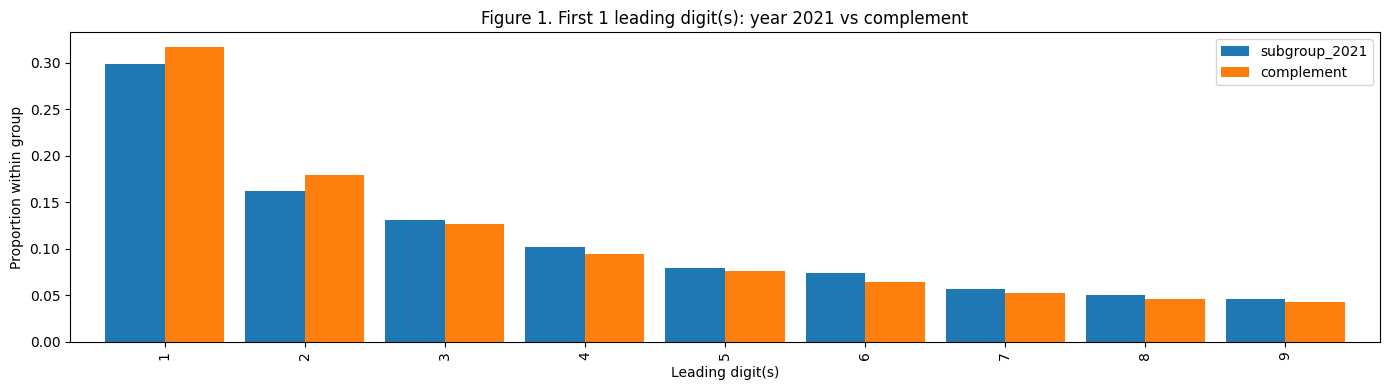

TV: 0.03487307629249081 subgroup n: 10684 complement n: 34486


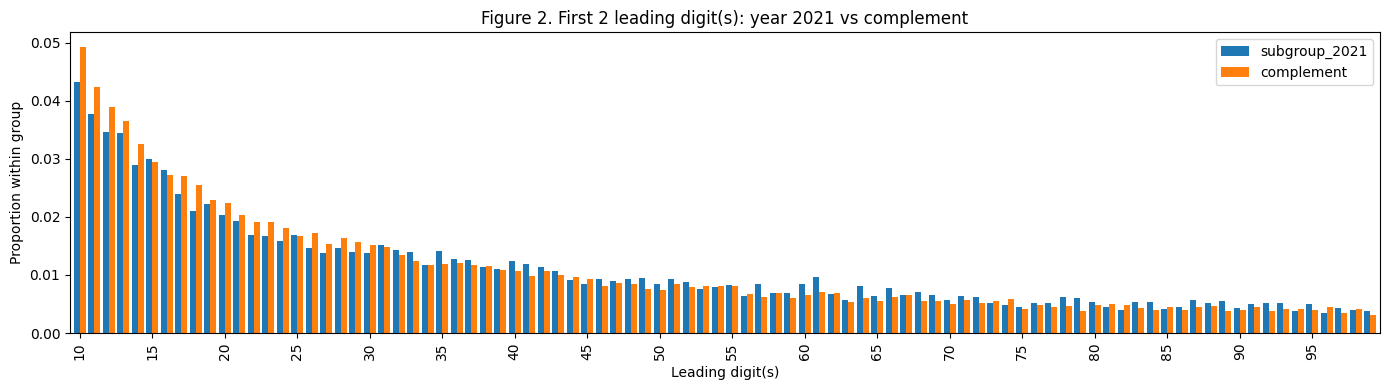

TV: 0.05567030224823399 subgroup n: 10088 complement n: 27973


In [8]:
import matplotlib.pyplot as plt
FIG = ROOT / 'figures/pre_emm_2026-10-05'
FIG.mkdir(parents=True, exist_ok=True)
for k, field in [(1,'first_digit'),(2,'first_2_digits')]:
    eligible = analysis[field].notna()
    mask = analysis.year.eq(2021)
    p = distribution(analysis.loc[eligible & mask,field],k)
    q = distribution(analysis.loc[eligible & ~mask,field],k)
    comparison = pd.DataFrame({'subgroup_2021':p,'complement':q})
    comparison.to_csv(OUT / f'year2021_distribution_k{k}.csv')
    ax = comparison.plot.bar(figsize=(14,4), width=.85)
    ax.set_title(f'Figure {k}. First {k} leading digit(s): year 2021 vs complement')
    ax.set_xlabel('Leading digit(s)'); ax.set_ylabel('Proportion within group')
    if k == 2:
        ax.set_xticks(range(0,90,5)); ax.set_xticklabels(comparison.index[::5], rotation=90)
    plt.tight_layout()
    plt.savefig(FIG / f'figure_{k}_year2021_k{k}.png',dpi=150)
    plt.show()
    print('TV:', tv_distance(p,q), 'subgroup n:', int((eligible & mask).sum()), 'complement n:', int((eligible & ~mask).sum()))


## 6. Tables 4–7: Country retention and descriptor coverage

Complete retention is complete weeks divided by candidate weeks. Positive retention also reflects genuine zero weeks and is not a missingness rate. Candidate weeks cover each country's observed interval, not a common global window. Report missing weeks and locations for every descriptor. The common core-complete cohort provides a fixed population for comparing quality measures.

In [9]:
"""Audit country retention and descriptor coverage before EMM."""
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import json
import pandas as pd

ROOT = Path.cwd()
OUT = ROOT/'data/processed/pre_emm_2026-10-05'
DESCRIPTORS = ['population','median_age','life_expectancy','population_density','gdp_per_capita']

def audit():
    started = datetime.now(ZoneInfo('Europe/Berlin')).isoformat()
    w = pd.read_csv(OUT/'validated_country_week.csv')
    country = w.groupby('country').agg(continent=('continent','first'),candidate_weeks=('complete','size'),
        complete_weeks=('complete','sum'),positive_weeks=('positive','sum'))
    country['complete_retention_pct'] = 100*country.complete_weeks/country.candidate_weeks
    country['positive_retention_pct'] = 100*country.positive_weeks/country.candidate_weeks
    country['zero_complete_weeks'] = country.complete_weeks-country.positive_weeks
    country.sort_values(['complete_retention_pct','country']).to_csv(OUT/'country_retention.csv')
    usable = w.loc[w.positive].copy()
    rows=[]
    missing=[]
    for c in DESCRIPTORS:
        flag=usable[c].isna()
        by_country=usable.groupby('country')[c].agg(['count','size','nunique'])
        rows.append({'descriptor':c,'eligible_positive_weeks':len(usable),'missing_weeks':int(flag.sum()),
            'missing_week_pct':100*flag.mean(),'locations_with_any_missing':int(usable.loc[flag,'country'].nunique()),
            'locations_entirely_missing':int(by_country['count'].eq(0).sum()),
            'locations_with_multiple_observed_values':int(by_country['nunique'].gt(1).sum())})
        for name, g in usable.loc[flag].groupby('country'):
            missing.append({'descriptor':c,'country':name,'missing_positive_weeks':len(g)})
    pd.DataFrame(rows).to_csv(OUT/'descriptor_coverage_audit.csv',index=False)
    pd.DataFrame(missing).to_csv(OUT/'descriptor_missing_locations.csv',index=False)
    core=DESCRIPTORS[:4]
    core_ok=usable[core].notna().all(axis=1)
    gdp_ok=usable[DESCRIPTORS].notna().all(axis=1)
    coverage=pd.DataFrame([
        {'analysis':'target_only','weeks':len(usable),'locations':usable.country.nunique()},
        {'analysis':'core_descriptors_complete','weeks':int(core_ok.sum()),'locations':usable.loc[core_ok,'country'].nunique()},
        {'analysis':'core_plus_GDP_complete','weeks':int(gdp_ok.sum()),'locations':usable.loc[gdp_ok,'country'].nunique()},
    ])
    coverage.to_csv(OUT/'analysis_population_coverage.csv',index=False)
    continent=w.groupby('continent').agg(candidate_weeks=('complete','size'),complete_weeks=('complete','sum'),positive_weeks=('positive','sum'),locations=('country','nunique'))
    continent['complete_retention_pct']=100*continent.complete_weeks/continent.candidate_weeks
    continent.to_csv(OUT/'continent_retention.csv')
    meta={'started_at':started,'finished_at':datetime.now(ZoneInfo('Europe/Berlin')).isoformat(),
          'candidate_locations':int(country.shape[0]),'positive_locations':int(usable.country.nunique()),
          'no_positive_locations':country.index[country.positive_weeks.eq(0)].tolist(),
          'interpretation':'Positive retention includes true zero weeks; it is not a missingness rate. Candidate weeks cover observed country intervals, not all pandemic weeks. Core complete cases are a sensitivity cohort, not an automatic mandatory exclusion.'}
    (OUT/'country_audit_metadata.json').write_text(json.dumps(meta,indent=2),encoding='utf-8')
    print(json.dumps(meta,indent=2))
    print(coverage.to_string(index=False))
    return country,pd.DataFrame(rows),coverage,continent

if __name__=='__main__':
    audit()


{
  "started_at": "2026-10-05T20:06:15.773326+02:00",
  "finished_at": "2026-10-05T20:06:15.990467+02:00",
  "candidate_locations": 239,
  "positive_locations": 231,
  "no_positive_locations": [
    "Cote d'Ivoire",
    "Hong Kong",
    "Macao",
    "North Korea",
    "Taiwan",
    "Transnistria",
    "Turkmenistan",
    "Western Sahara"
  ],
  "interpretation": "Positive retention includes true zero weeks; it is not a missingness rate. Candidate weeks cover observed country intervals, not all pandemic weeks. Core complete cases are a sensitivity cohort, not an automatic mandatory exclusion."
}
                 analysis  weeks  locations
              target_only  45170        231
core_descriptors_complete  44567        226
   core_plus_GDP_complete  40688        194


In [10]:
country, descriptor_audit, cohort_coverage, continent_retention = audit()
display(country.sort_values('complete_retention_pct').head(15))
display(descriptor_audit)
display(cohort_coverage)
display(pd.read_csv(OUT/'descriptor_missing_locations.csv'))


{
  "started_at": "2026-10-05T20:06:16.000092+02:00",
  "finished_at": "2026-10-05T20:06:16.212409+02:00",
  "candidate_locations": 239,
  "positive_locations": 231,
  "no_positive_locations": [
    "Cote d'Ivoire",
    "Hong Kong",
    "Macao",
    "North Korea",
    "Taiwan",
    "Transnistria",
    "Turkmenistan",
    "Western Sahara"
  ],
  "interpretation": "Positive retention includes true zero weeks; it is not a missingness rate. Candidate weeks cover observed country intervals, not all pandemic weeks. Core complete cases are a sensitivity cohort, not an automatic mandatory exclusion."
}
                 analysis  weeks  locations
              target_only  45170        231
core_descriptors_complete  44567        226
   core_plus_GDP_complete  40688        194


,continent,candidate_weeks,complete_weeks,positive_weeks,complete_retention_pct,positive_retention_pct,zero_complete_weeks
country,,,,,,,
Cote d'Ivoire,Africa,164,0,0,0.000000,0.000000,0
Hong Kong,Asia,241,0,0,0.000000,0.000000,0
Macao,Asia,181,0,0,0.000000,0.000000,0
Taiwan,Asia,217,0,0,0.000000,0.000000,0
Western Sahara,Africa,1,0,0,0.000000,0.000000,0
Transnistria,Europe,48,0,0,0.000000,0.000000,0
United States,North America,348,175,173,50.287356,49.712644,2
France,Europe,348,181,167,52.011494,47.988506,14
Germany,Europe,348,183,180,52.586207,51.724138,3


,descriptor,eligible_positive_weeks,missing_weeks,missing_week_pct,locations_with_any_missing,locations_entirely_missing,locations_with_multiple_observed_values
0,population,45170,1,0.002214,1,1,0
1,median_age,45170,1,0.002214,1,1,0
2,life_expectancy,45170,1,0.002214,1,1,0
3,population_density,45170,603,1.334957,5,5,0
4,gdp_per_capita,45170,4296,9.510737,36,36,0


,analysis,weeks,locations
0,target_only,45170,231
1,core_descriptors_complete,44567,226
2,core_plus_GDP_complete,40688,194


,descriptor,country,missing_positive_weeks
0,population,Pitcairn,1
1,median_age,Pitcairn,1
2,life_expectancy,Pitcairn,1
3,population_density,Guernsey,128
4,population_density,Jersey,151
5,population_density,Kosovo,186
6,population_density,Pitcairn,1
7,population_density,Saint Barthelemy,137
8,gdp_per_capita,American Samoa,58
9,gdp_per_capita,Anguilla,81


## 7. Figures 3–4: Retention and coverage loss

Figure 3 reports complete-week retention by continent. Figure 4 reports descriptor missingness among positive complete weeks. They describe the analysis population, not pandemic anomalies.

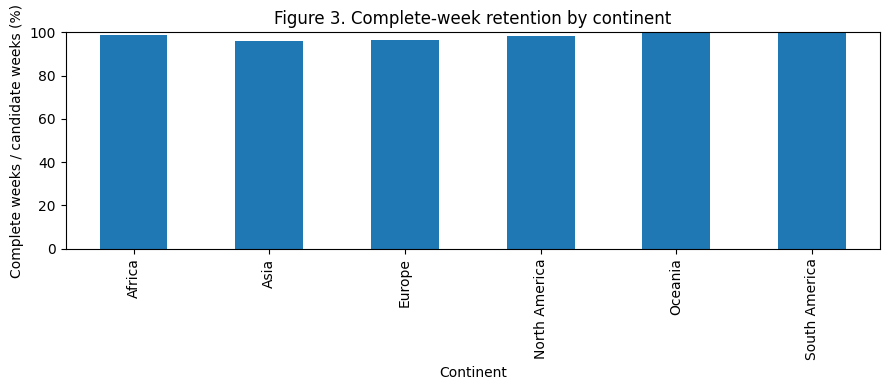

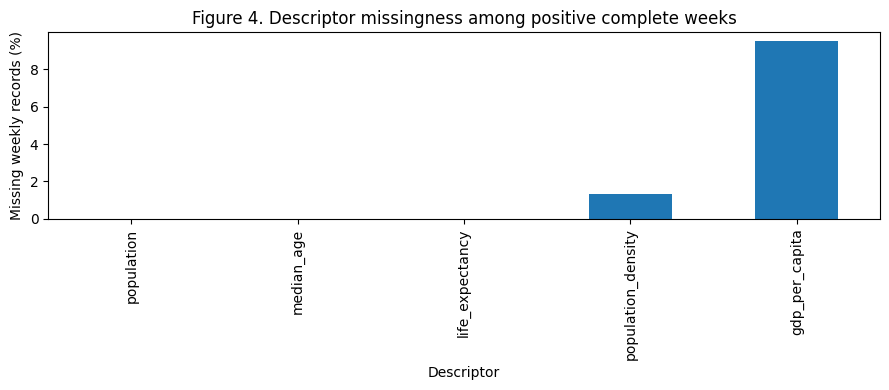

In [11]:
ax = continent_retention.complete_retention_pct.plot.bar(figsize=(9,4),ylim=(0,100))
ax.set_title('Figure 3. Complete-week retention by continent')
ax.set_ylabel('Complete weeks / candidate weeks (%)'); ax.set_xlabel('Continent')
plt.tight_layout(); plt.savefig(FIG/'figure_3_continent_retention.png',dpi=150); plt.show()
ax = descriptor_audit.set_index('descriptor').missing_week_pct.plot.bar(figsize=(9,4))
ax.set_title('Figure 4. Descriptor missingness among positive complete weeks')
ax.set_ylabel('Missing weekly records (%)'); ax.set_xlabel('Descriptor')
plt.tight_layout(); plt.savefig(FIG/'figure_4_descriptor_missingness.png',dpi=150); plt.show()


## 8. Tables 8–9: Model checks and fixed cohorts

Check known probabilities, normalization, TV=0 for identical distributions, TV=1 for disjoint distributions, symmetry and explicit errors for empty/invalid inputs. Export target-only, core-complete and core-plus-GDP cohorts for K=1/K=2. Compare measures within the same cohort; use the other cohorts for sensitivity checks.

In [12]:
"""Verify model edge cases and export fixed comparison cohorts."""
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import json
import pandas as pd
import sys
sys.path.insert(0, str(Path.cwd()))
from scripts.run_pre_emm_experiment import distribution, tv_distance

ROOT=Path.cwd()
OUT=ROOT/'data/processed/pre_emm_2026-10-05'

def check_and_freeze():
    started=datetime.now(ZoneInfo('Europe/Berlin')).isoformat()
    checks=[]
    def verify(name, condition):
        assert condition, name
        checks.append({'check':name,'passed':True})
    p=distribution(pd.Series(['1','1','2',None]),1)
    verify('known probabilities: 1=2/3, 2=1/3',abs(p['1']-2/3)<1e-12 and abs(p['2']-1/3)<1e-12)
    verify('probability sum = 1',abs(p.sum()-1)<1e-12)
    verify('identical distributions have TV = 0',tv_distance(p,p)==0)
    q=distribution(pd.Series(['9','9']),1)
    verify('disjoint distributions have TV = 1',abs(tv_distance(p,q)-1)<1e-12)
    verify('TV symmetry',abs(tv_distance(p,q)-tv_distance(q,p))<1e-12)
    two=distribution(pd.Series(['7','12','123',None]),2)
    verify('K=2 excludes one-digit values, no padding',two['12']==1 and len(two)==90)
    for name, values,k in [('empty group',[],1),('insufficient length',['7'],2),('invalid zero',['0'],1),('invalid K',['1'],0)]:
        caught=False
        try: distribution(pd.Series(values,dtype='object'),k)
        except ValueError: caught=True
        verify(name+' raises explicit error',caught)
    pd.DataFrame(checks).to_csv(OUT/'model_checks.csv',index=False)
    w=pd.read_csv(OUT/'validated_country_week.csv',dtype={'first_digit':'string','first_2_digits':'string','first_3_digits':'string'})
    core=['population','median_age','life_expectancy','population_density']
    summary=[]
    for k,field in [(1,'first_digit'),(2,'first_2_digits')]:
        for label, columns in [('target_only',[]),('core_complete',core),('core_gdp_complete',core+['gdp_per_capita'])]:
            mask=w[field].notna() & w[columns].notna().all(axis=1)
            cohort=w.loc[mask].copy()
            filename=f'cohort_k{k}_{label}.csv'
            cohort.to_csv(OUT/filename,index=False)
            verify(filename+' has unique country-week keys',not cohort.duplicated(['country','week_start']).any())
            summary.append({'cohort':label,'K':k,'rows':len(cohort),'locations':cohort.country.nunique(),'filename':filename})
    pd.DataFrame(checks).to_csv(OUT/'model_checks.csv',index=False)
    pd.DataFrame(summary).to_csv(OUT/'fixed_cohort_summary.csv',index=False)
    meta={'started_at':started,'finished_at':datetime.now(ZoneInfo('Europe/Berlin')).isoformat(),'checks_passed':len(checks),
          'recommended_main':'cohort_k1_core_complete.csv','secondary':'cohort_k2_core_complete.csv',
          'sensitivity':'target_only and core_gdp_complete cohorts',
          'caveat':'K cohorts differ; compare quality measures within a fixed cohort. Locations/country-weeks are not independent subjects.'}
    (OUT/'model_cohort_metadata.json').write_text(json.dumps(meta,indent=2),encoding='utf-8')
    print(json.dumps(meta,indent=2))
    return pd.DataFrame(checks),pd.DataFrame(summary)

if __name__=='__main__': check_and_freeze()


{
  "started_at": "2026-10-05T20:06:16.504251+02:00",
  "finished_at": "2026-10-05T20:06:18.185513+02:00",
  "checks_passed": 16,
  "recommended_main": "cohort_k1_core_complete.csv",
  "secondary": "cohort_k2_core_complete.csv",
  "sensitivity": "target_only and core_gdp_complete cohorts",
  "caveat": "K cohorts differ; compare quality measures within a fixed cohort. Locations/country-weeks are not independent subjects."
}


In [13]:
checks, fixed_cohorts = check_and_freeze()
display(checks)
display(fixed_cohorts)

{
  "started_at": "2026-10-05T20:06:18.194211+02:00",
  "finished_at": "2026-10-05T20:06:19.901276+02:00",
  "checks_passed": 16,
  "recommended_main": "cohort_k1_core_complete.csv",
  "secondary": "cohort_k2_core_complete.csv",
  "sensitivity": "target_only and core_gdp_complete cohorts",
  "caveat": "K cohorts differ; compare quality measures within a fixed cohort. Locations/country-weeks are not independent subjects."
}


,check,passed
0,"known probabilities: 1=2/3, 2=1/3",True
1,probability sum = 1,True
2,identical distributions have TV = 0,True
3,disjoint distributions have TV = 1,True
4,TV symmetry,True
5,"K=2 excludes one-digit values, no padding",True
6,empty group raises explicit error,True
7,insufficient length raises explicit error,True
8,invalid zero raises explicit error,True
9,invalid K raises explicit error,True


,cohort,K,rows,locations,filename
0,target_only,1,45170,231,cohort_k1_target_only.csv
1,core_complete,1,44567,226,cohort_k1_core_complete.csv
2,core_gdp_complete,1,40688,194,cohort_k1_core_gdp_complete.csv
3,target_only,2,38061,230,cohort_k2_target_only.csv
4,core_complete,2,37590,226,cohort_k2_core_complete.csv
5,core_gdp_complete,2,34730,194,cohort_k2_core_gdp_complete.csv


## 9. Table 10 and Figures 5–6: Compare three distances

Use the same core-complete cohort within each K and six fixed rules. P is the subgroup digit distribution; Q is its complement.

TV: $\frac12\sum_d |P_d-Q_d|$.

Jensen–Shannon divergence: $\frac12 KL(P\Vert M)+\frac12 KL(Q\Vert M)$, where $M=(P+Q)/2$ and $KL(P\Vert M)=\sum_{P_d>0}P_d\log_2(P_d/M_d)$. Base-2 JS divergence lies in [0,1]; it is not the square-root JS distance.

Hellinger: $\sqrt{\frac12\sum_d(\sqrt{P_d}-\sqrt{Q_d})^2}$, in [0,1].

All quantify distributional differences, not p-values; no support penalty is included. Compare ranks within K, not numerical magnitudes between measures or K.

In [14]:
"""Compare three distances on fixed cohorts and predeclared subgroups."""
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import json
import numpy as np
import pandas as pd
from scripts.run_pre_emm_experiment import distribution, tv_distance

ROOT=Path.cwd()
OUT=ROOT/'data/processed/pre_emm_2026-10-05'

def distances(p,q):
    p,q=p.to_numpy(),q.to_numpy()
    m=(p+q)/2
    def kl(a):
        positive=a>0
        return float(np.sum(a[positive]*np.log2(a[positive]/m[positive])))
    return {'TV':float(.5*np.abs(p-q).sum()),
            'JS_divergence_bits':.5*(kl(p)+kl(q)),
            'Hellinger':float(np.sqrt(.5*np.sum((np.sqrt(p)-np.sqrt(q))**2)))}

def compare():
    started=datetime.now(ZoneInfo('Europe/Berlin')).isoformat()
    rows=[]
    for k,field in [(1,'first_digit'),(2,'first_2_digits')]:
        d=pd.read_csv(OUT/f'cohort_k{k}_core_complete.csv',dtype={field:'string'})
        cuts=d.groupby('country').population_density.first().quantile([.25,.75])
        masks={'continent=Europe':d.continent.eq('Europe'),'continent=Asia':d.continent.eq('Asia'),
            'year=2020':d.year.eq(2020),'year=2021':d.year.eq(2021),
            'population_density<=Q1':d.population_density.le(cuts.loc[.25]),
            'population_density>=Q3':d.population_density.ge(cuts.loc[.75])}
        for name,mask in masks.items():
            p=distribution(d.loc[mask,field],k)
            q=distribution(d.loc[~mask,field],k)
            scores=distances(p,q)
            assert all(0<=v<=1+1e-12 for v in scores.values())
            rows.append({'K':k,'subgroup':name,'cohort_rows':len(d),'subgroup_n':int(mask.sum()),
                'complement_n':int((~mask).sum()),'support':float(mask.mean()),**scores})
    result=pd.DataFrame(rows)
    measures=['TV','JS_divergence_bits','Hellinger']
    for c in measures:
        result[c+'_rank']=result.groupby('K')[c].rank(method='min',ascending=False).astype(int)
    result.to_csv(OUT/'quality_measure_comparison.csv',index=False)
    check=pd.Series([1.,0.]); opposite=pd.Series([0.,1.])
    assert all(abs(v)<1e-12 for v in distances(check,check).values())
    assert all(abs(v-1)<1e-12 for v in distances(check,opposite).values())
    meta={'started_at':started,'finished_at':datetime.now(ZoneInfo('Europe/Berlin')).isoformat(),
        'comparison':'same core-complete cohort within each K; subgroup vs complement',
        'JS_log_base':2,'Hellinger_normalization':'sqrt(0.5 * sum((sqrt(p)-sqrt(q))^2))',
        'search':'six manually specified rules; no automatic EMM search',
        'interpretation':'Distances are candidate ranking scores, not p-values. Scores across metrics or K are not directly comparable. No support penalty.'}
    (OUT/'quality_comparison_metadata.json').write_text(json.dumps(meta,indent=2),encoding='utf-8')
    print(json.dumps(meta,indent=2))
    return result

if __name__=='__main__': compare()


{
  "started_at": "2026-10-05T20:06:19.920312+02:00",
  "finished_at": "2026-10-05T20:06:20.160457+02:00",
  "comparison": "same core-complete cohort within each K; subgroup vs complement",
  "JS_log_base": 2,
  "Hellinger_normalization": "sqrt(0.5 * sum((sqrt(p)-sqrt(q))^2))",
  "search": "six manually specified rules; no automatic EMM search",
  "interpretation": "Distances are candidate ranking scores, not p-values. Scores across metrics or K are not directly comparable. No support penalty."
}


{
  "started_at": "2026-10-05T20:06:20.167941+02:00",
  "finished_at": "2026-10-05T20:06:20.398842+02:00",
  "comparison": "same core-complete cohort within each K; subgroup vs complement",
  "JS_log_base": 2,
  "Hellinger_normalization": "sqrt(0.5 * sum((sqrt(p)-sqrt(q))^2))",
  "search": "six manually specified rules; no automatic EMM search",
  "interpretation": "Distances are candidate ranking scores, not p-values. Scores across metrics or K are not directly comparable. No support penalty."
}


,K,subgroup,cohort_rows,subgroup_n,complement_n,support,TV,JS_divergence_bits,Hellinger,TV_rank,JS_divergence_bits_rank,Hellinger_rank
0,1,continent=Europe,44567,12820,31747,0.287657,0.009692,0.000097,0.008182,6,6,6
1,1,continent=Asia,44567,8904,35663,0.199789,0.015396,0.000248,0.013105,2,2,2
2,1,year=2020,44567,8249,36318,0.185092,0.014732,0.000202,0.011829,3,4,4
3,1,year=2021,44567,10493,34074,0.235443,0.034470,0.000974,0.025981,1,1,1
4,1,population_density<=Q1,44567,10865,33702,0.243790,0.013325,0.000215,0.012220,4,3,3
5,1,population_density>=Q3,44567,10553,34014,0.236790,0.013082,0.000169,0.010817,5,5,5
6,2,continent=Europe,37590,11694,25896,0.311093,0.042572,0.002201,0.039078,6,6,6
7,2,continent=Asia,37590,7994,29596,0.212663,0.046183,0.003043,0.045976,4,4,4
8,2,year=2020,37590,6963,30627,0.185235,0.052300,0.003188,0.047042,2,2,2
9,2,year=2021,37590,9944,27646,0.264538,0.055433,0.003265,0.047597,1,1,1


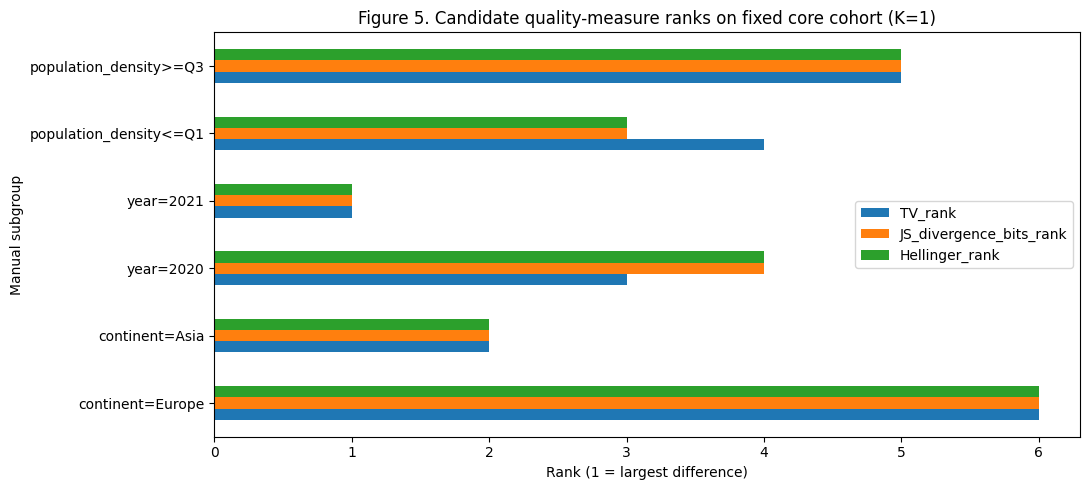

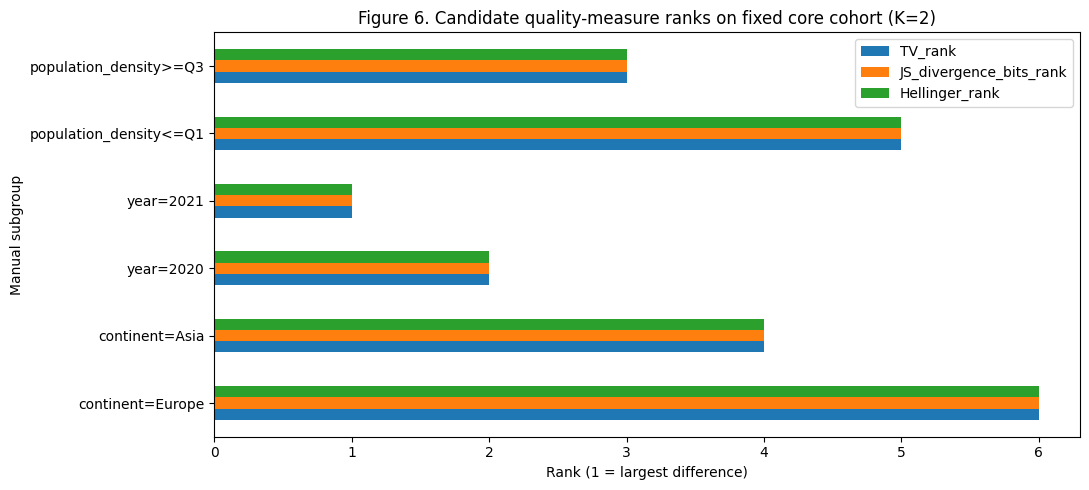

In [15]:
comparison=compare()
display(comparison)
for k in (1,2):
    ranks=comparison.loc[comparison.K.eq(k)].set_index('subgroup')[['TV_rank','JS_divergence_bits_rank','Hellinger_rank']]
    ax=ranks.plot.barh(figsize=(11,5))
    ax.set_title(f'Figure {k+4}. Candidate quality-measure ranks on fixed core cohort (K={k})')
    ax.set_xlabel('Rank (1 = largest difference)'); ax.set_ylabel('Manual subgroup')
    plt.tight_layout(); plt.savefig(FIG/f'figure_{k+4}_quality_ranks_k{k}.png',dpi=150); plt.show()


## 10. Tables 11–12 and Figure 7: Bins and support

Numeric descriptors use country-based 25/50/75 percentiles from the K1 core cohort, shared across K1/K2. Ties may make bins unequal. Initial screening requires at least 100 weeks and 10 locations in each group. This is an engineering choice rather than a significance guarantee. Rules cover continents, years and quartile bins; conjunctions have not been searched.

In [16]:
"""Prepare fixed country-based bins and inspect subgroup support."""
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import json
import pandas as pd

ROOT=Path.cwd()
OUT=ROOT/'data/processed/pre_emm_2026-10-05'
NUMERIC=['population','median_age','life_expectancy','population_density']

def prepare():
    started=datetime.now(ZoneInfo('Europe/Berlin')).isoformat()
    base=pd.read_csv(OUT/'cohort_k1_core_complete.csv')
    # Require a single observed value per country before country-based bins.
    variation=base.groupby('country')[NUMERIC].nunique()
    assert variation.le(1).all().all(), 'Time-varying descriptors need a reference-date policy'
    country=base.groupby('country')[NUMERIC].first()
    thresholds=[]
    for c in NUMERIC:
        for quantile,value in country[c].quantile([.25,.5,.75]).items():
            thresholds.append({'descriptor':c,'quantile':quantile,'threshold':value,
                'reference_locations':len(country),'reference':'K1 core-complete countries, one value per country'})
    cuts=pd.DataFrame(thresholds)
    cuts.to_csv(OUT/'descriptor_bin_thresholds.csv',index=False)
    support=[]
    for k in (1,2):
        d=pd.read_csv(OUT/f'cohort_k{k}_core_complete.csv')
        rules={f'continent={v}':d.continent.eq(v) for v in sorted(d.continent.unique())}
        rules.update({f'year={v}':d.year.eq(v) for v in sorted(d.year.unique())})
        for c in NUMERIC:
            q=cuts.loc[cuts.descriptor.eq(c)].set_index('quantile').threshold
            rules[f'{c}:Q1']=d[c].le(q.loc[.25])
            rules[f'{c}:Q2']=d[c].gt(q.loc[.25]) & d[c].le(q.loc[.5])
            rules[f'{c}:Q3']=d[c].gt(q.loc[.5]) & d[c].le(q.loc[.75])
            rules[f'{c}:Q4']=d[c].gt(q.loc[.75])
            labels=pd.Series(index=d.index,dtype='string')
            for label in ('Q1','Q2','Q3','Q4'):
                labels.loc[rules[f'{c}:{label}']]=label
            assert labels.notna().all()
            d[c+'_bin']=labels
        d.to_csv(OUT/f'cohort_k{k}_core_binned.csv',index=False)
        for name,mask in rules.items():
            n=int(mask.sum()); n_other=len(d)-n
            countries=int(d.loc[mask,'country'].nunique())
            other_countries=int(d.loc[~mask,'country'].nunique())
            support.append({'K':k,'rule':name,'subgroup_weeks':n,'complement_weeks':n_other,
                'subgroup_locations':countries,'complement_locations':other_countries,
                'support_fraction':n/len(d),'candidate_minimum_pass':n>=100 and n_other>=100 and countries>=10 and other_countries>=10})
    table=pd.DataFrame(support)
    table.to_csv(OUT/'candidate_rule_support.csv',index=False)
    meta={'started_at':started,'finished_at':datetime.now(ZoneInfo('Europe/Berlin')).isoformat(),
        'threshold_reference':'one value per country in K1 core-complete cohort; shared by K1/K2',
        'intervals':'Q1 <= p25; Q2 (p25,p50]; Q3 (p50,p75]; Q4 > p75; ties may produce unequal sizes',
        'candidate_filter':{'min_subgroup_weeks':100,'min_complement_weeks':100,'min_subgroup_locations':10,'min_complement_locations':10},
        'filter_status':'engineering screening choice, not a statistical guarantee; check threshold sensitivity later',
        'dependence':'Weeks are correlated within countries; unique-country count is coverage, not an independent sample size.',
        'rule_count':len(table),'passing_rules':int(table.candidate_minimum_pass.sum())}
    (OUT/'descriptor_rule_metadata.json').write_text(json.dumps(meta,indent=2),encoding='utf-8')
    print(json.dumps(meta,indent=2))
    return cuts,table

if __name__=='__main__': prepare()


{
  "started_at": "2026-10-05T20:06:20.768165+02:00",
  "finished_at": "2026-10-05T20:06:21.661270+02:00",
  "threshold_reference": "one value per country in K1 core-complete cohort; shared by K1/K2",
  "intervals": "Q1 <= p25; Q2 (p25,p50]; Q3 (p50,p75]; Q4 > p75; ties may produce unequal sizes",
  "candidate_filter": {
    "min_subgroup_weeks": 100,
    "min_complement_weeks": 100,
    "min_subgroup_locations": 10,
    "min_complement_locations": 10
  },
  "filter_status": "engineering screening choice, not a statistical guarantee; check threshold sensitivity later",
  "dependence": "Weeks are correlated within countries; unique-country count is coverage, not an independent sample size.",
  "rule_count": 58,
  "passing_rules": 58
}


{
  "started_at": "2026-10-05T20:06:21.669290+02:00",
  "finished_at": "2026-10-05T20:06:22.573342+02:00",
  "threshold_reference": "one value per country in K1 core-complete cohort; shared by K1/K2",
  "intervals": "Q1 <= p25; Q2 (p25,p50]; Q3 (p50,p75]; Q4 > p75; ties may produce unequal sizes",
  "candidate_filter": {
    "min_subgroup_weeks": 100,
    "min_complement_weeks": 100,
    "min_subgroup_locations": 10,
    "min_complement_locations": 10
  },
  "filter_status": "engineering screening choice, not a statistical guarantee; check threshold sensitivity later",
  "dependence": "Weeks are correlated within countries; unique-country count is coverage, not an independent sample size.",
  "rule_count": 58,
  "passing_rules": 58
}


,descriptor,quantile,threshold,reference_locations,reference
0,population,0.25,3.988418e+05,226,"K1 core-complete countries, one value per country"
1,population,0.50,5.464996e+06,226,"K1 core-complete countries, one value per country"
2,population,0.75,2.249732e+07,226,"K1 core-complete countries, one value per country"
3,median_age,0.25,2.185775e+01,226,"K1 core-complete countries, one value per country"
4,median_age,0.50,3.122850e+01,226,"K1 core-complete countries, one value per country"
5,median_age,0.75,3.904025e+01,226,"K1 core-complete countries, one value per country"
6,life_expectancy,0.25,6.838933e+01,226,"K1 core-complete countries, one value per country"
7,life_expectancy,0.50,7.456790e+01,226,"K1 core-complete countries, one value per country"
8,life_expectancy,0.75,7.852352e+01,226,"K1 core-complete countries, one value per country"
9,population_density,0.25,3.885678e+01,226,"K1 core-complete countries, one value per country"


,K,rule,subgroup_weeks,complement_weeks,subgroup_locations,complement_locations,support_fraction,candidate_minimum_pass
0,1,continent=Africa,10251,34316,56,170,0.230013,True
1,1,continent=Asia,8904,35663,45,181,0.199789,True
2,1,continent=Europe,12820,31747,48,178,0.287657,True
3,1,continent=North America,7152,37415,40,186,0.160477,True
4,1,continent=Oceania,2108,42459,23,203,0.047300,True
5,1,continent=South America,3332,41235,14,212,0.074764,True
6,1,year=2020,8249,36318,214,225,0.185092,True
7,1,year=2021,10493,34074,216,226,0.235443,True
8,1,year=2022,10373,34194,225,225,0.232751,True
9,1,year=2023,6263,38304,206,226,0.140530,True


,K,rule,subgroup_weeks,complement_weeks,subgroup_locations,complement_locations,support_fraction,candidate_minimum_pass


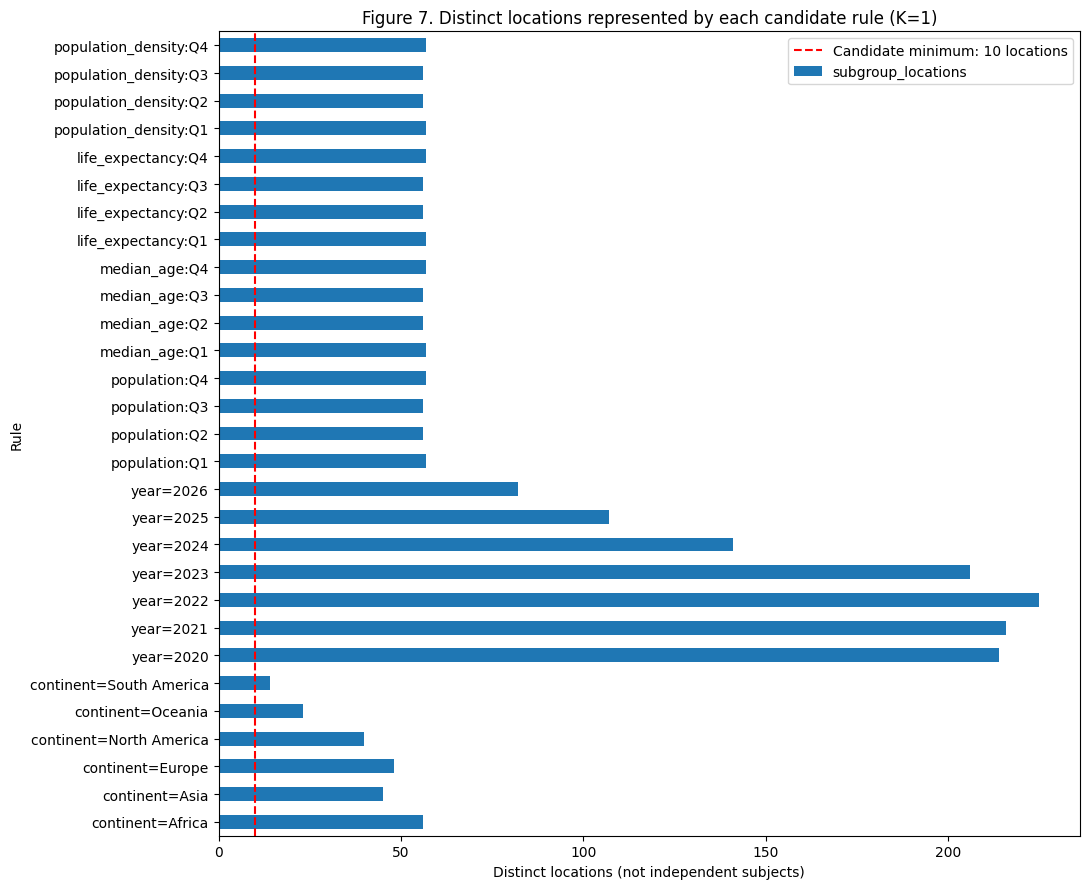

In [17]:
thresholds, rule_support=prepare()
display(thresholds)
display(rule_support)
display(rule_support.loc[~rule_support.candidate_minimum_pass])
ax=rule_support.loc[rule_support.K.eq(1)].set_index('rule').subgroup_locations.plot.barh(figsize=(11,9))
ax.axvline(10,color='red',linestyle='--',label='Candidate minimum: 10 locations')
ax.set_title('Figure 7. Distinct locations represented by each candidate rule (K=1)')
ax.set_xlabel('Distinct locations (not independent subjects)'); ax.set_ylabel('Rule'); ax.legend()
plt.tight_layout(); plt.savefig(FIG/'figure_7_rule_location_support.png',dpi=150); plt.show()


## 11. Tables 13–15 and Figures 8–9: All predefined scores and support sensitivity

Compare 29 single-condition rules per K. Loose screening uses 50 weeks/5 locations per group; baseline 100/10; strict 500/30. Inspect retained rules and top five ranks. High scores indicate distributional differences, not fraud. These are fixed-rule experiments rather than automatic EMM search.

In [18]:
"""Score predefined single-condition rules and inspect support sensitivity."""
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import json
import pandas as pd
from scripts.run_pre_emm_experiment import distribution
from scripts.compare_quality_measures import distances

ROOT=Path.cwd()
OUT=ROOT/'data/processed/pre_emm_2026-10-05'
MEASURES=['TV','JS_divergence_bits','Hellinger']

def score_rules():
    started=datetime.now(ZoneInfo('Europe/Berlin')).isoformat()
    rows=[]
    for k,field in [(1,'first_digit'),(2,'first_2_digits')]:
        d=pd.read_csv(OUT/f'cohort_k{k}_core_binned.csv',dtype={field:'string'})
        rules={f'continent={v}':d.continent.eq(v) for v in sorted(d.continent.unique())}
        rules.update({f'year={v}':d.year.eq(v) for v in sorted(d.year.unique())})
        for c in ['population','median_age','life_expectancy','population_density']:
            rules.update({f'{c}:{v}':d[c+'_bin'].eq(v) for v in ['Q1','Q2','Q3','Q4']})
        for name,mask in rules.items():
            if not mask.any() or mask.all():
                continue
            p=distribution(d.loc[mask,field],k)
            q=distribution(d.loc[~mask,field],k)
            rows.append({'K':k,'rule':name,'cohort_rows':len(d),'subgroup_weeks':int(mask.sum()),
                'complement_weeks':int((~mask).sum()),'subgroup_locations':d.loc[mask,'country'].nunique(),
                'complement_locations':d.loc[~mask,'country'].nunique(),**distances(p,q)})
    scored=pd.DataFrame(rows)
    assert len(scored)==58
    for measure in MEASURES:
        scored[measure+'_rank']=scored.groupby('K')[measure].rank(ascending=False,method='min').astype(int)
    scored.to_csv(OUT/'prepared_rule_scores.csv',index=False)
    policies={'relaxed':(50,5),'baseline':(100,10),'strict':(500,30)}
    retained=[]; top=[]
    for k in (1,2):
        subset=scored.loc[scored.K.eq(k)]
        for policy,(weeks,locations) in policies.items():
            eligible=subset.loc[(subset.subgroup_weeks>=weeks)&(subset.complement_weeks>=weeks)&
                (subset.subgroup_locations>=locations)&(subset.complement_locations>=locations)]
            retained.append({'K':k,'policy':policy,'minimum_weeks_each':weeks,
                'minimum_locations_each':locations,'rules_retained':len(eligible),'rules_excluded':len(subset)-len(eligible)})
            for measure in MEASURES:
                for rank,(_,row) in enumerate(eligible.sort_values([measure,'rule'],ascending=[False,True]).head(5).iterrows(),1):
                    top.append({'K':k,'policy':policy,'measure':measure,'rank':rank,'rule':row.rule,'score':row[measure]})
    sensitivity=pd.DataFrame(retained)
    top=pd.DataFrame(top)
    sensitivity.to_csv(OUT/'support_policy_summary.csv',index=False)
    top.to_csv(OUT/'support_policy_top5.csv',index=False)
    meta={'started_at':started,'finished_at':datetime.now(ZoneInfo('Europe/Berlin')).isoformat(),
        'rules_per_K':29,'policies':policies,'search':'predeclared single-condition rules only',
        'limitations':'Threshold sensitivity is descriptive; does not establish significance or correct country/time dependence. No EMM search or rule conjunctions.'}
    (OUT/'prepared_rule_score_metadata.json').write_text(json.dumps(meta,indent=2),encoding='utf-8')
    print(json.dumps(meta,indent=2))
    return scored,sensitivity,top

if __name__=='__main__': score_rules()


{
  "started_at": "2026-10-05T20:06:22.968253+02:00",
  "finished_at": "2026-10-05T20:06:23.626952+02:00",
  "rules_per_K": 29,
  "policies": {
    "relaxed": [
      50,
      5
    ],
    "baseline": [
      100,
      10
    ],
    "strict": [
      500,
      30
    ]
  },
  "search": "predeclared single-condition rules only",
  "limitations": "Threshold sensitivity is descriptive; does not establish significance or correct country/time dependence. No EMM search or rule conjunctions."
}


{
  "started_at": "2026-10-05T20:06:23.634830+02:00",
  "finished_at": "2026-10-05T20:06:24.274128+02:00",
  "rules_per_K": 29,
  "policies": {
    "relaxed": [
      50,
      5
    ],
    "baseline": [
      100,
      10
    ],
    "strict": [
      500,
      30
    ]
  },
  "search": "predeclared single-condition rules only",
  "limitations": "Threshold sensitivity is descriptive; does not establish significance or correct country/time dependence. No EMM search or rule conjunctions."
}


,K,rule,cohort_rows,subgroup_weeks,complement_weeks,subgroup_locations,complement_locations,TV,JS_divergence_bits,Hellinger,TV_rank,JS_divergence_bits_rank,Hellinger_rank
12,1,year=2026,44567,1480,43087,82,226,0.057400,0.004424,0.055430,1,1,1
11,1,year=2025,44567,3300,41267,107,226,0.050066,0.002072,0.037908,2,2,2
7,1,year=2021,44567,10493,34074,216,226,0.034470,0.000974,0.025981,3,4,4
5,1,continent=South America,44567,3332,41235,14,212,0.030838,0.000884,0.024756,4,5,5
3,1,continent=North America,44567,7152,37415,40,186,0.028577,0.000992,0.026234,5,3,3
10,1,year=2024,44567,4409,40158,141,226,0.024285,0.000735,0.022578,6,6,6
0,1,continent=Africa,44567,10251,34316,56,170,0.023146,0.000456,0.017788,7,10,10
21,1,life_expectancy:Q1,44567,9743,34824,57,169,0.020156,0.000458,0.017826,8,9,9
17,1,median_age:Q1,44567,9278,35289,57,169,0.020148,0.000519,0.018962,9,7,7
18,1,median_age:Q2,44567,11147,33420,56,170,0.018870,0.000388,0.016398,10,12,12


,K,policy,minimum_weeks_each,minimum_locations_each,rules_retained,rules_excluded
0,1,relaxed,50,5,29,0
1,1,baseline,100,10,29,0
2,1,strict,500,30,27,2
3,2,relaxed,50,5,29,0
4,2,baseline,100,10,29,0
5,2,strict,500,30,27,2


,K,policy,measure,rank,rule,score
0,1,relaxed,TV,1,year=2026,0.057400
1,1,relaxed,TV,2,year=2025,0.050066
2,1,relaxed,TV,3,year=2021,0.034470
3,1,relaxed,TV,4,continent=South America,0.030838
4,1,relaxed,TV,5,continent=North America,0.028577
...,...,...,...,...,...,...
85,2,strict,Hellinger,1,year=2026,0.151910
86,2,strict,Hellinger,2,year=2025,0.104110
87,2,strict,Hellinger,3,year=2024,0.066656
88,2,strict,Hellinger,4,population:Q1,0.060434


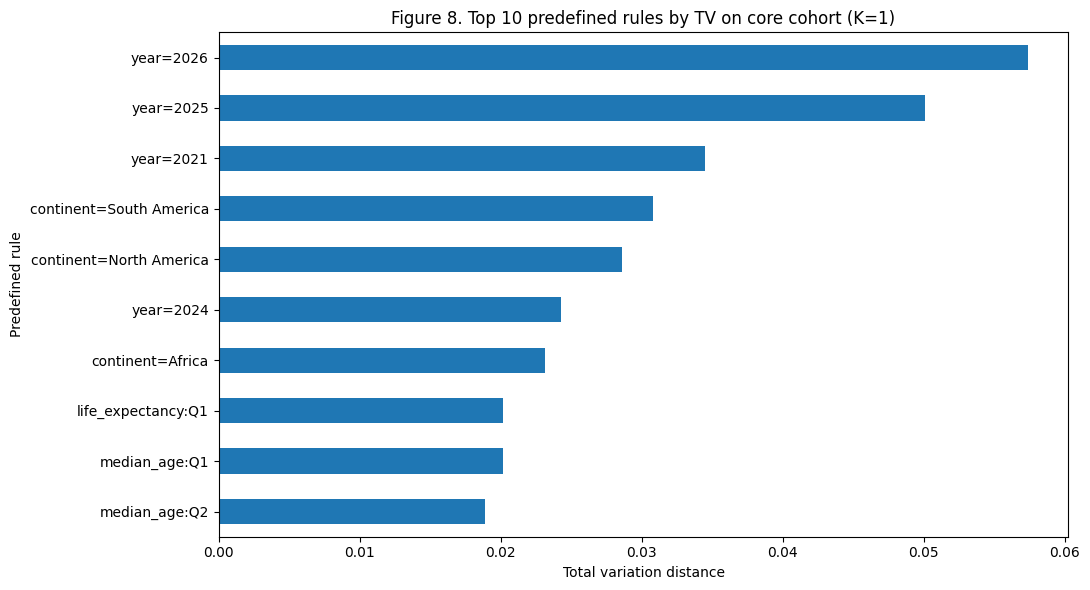

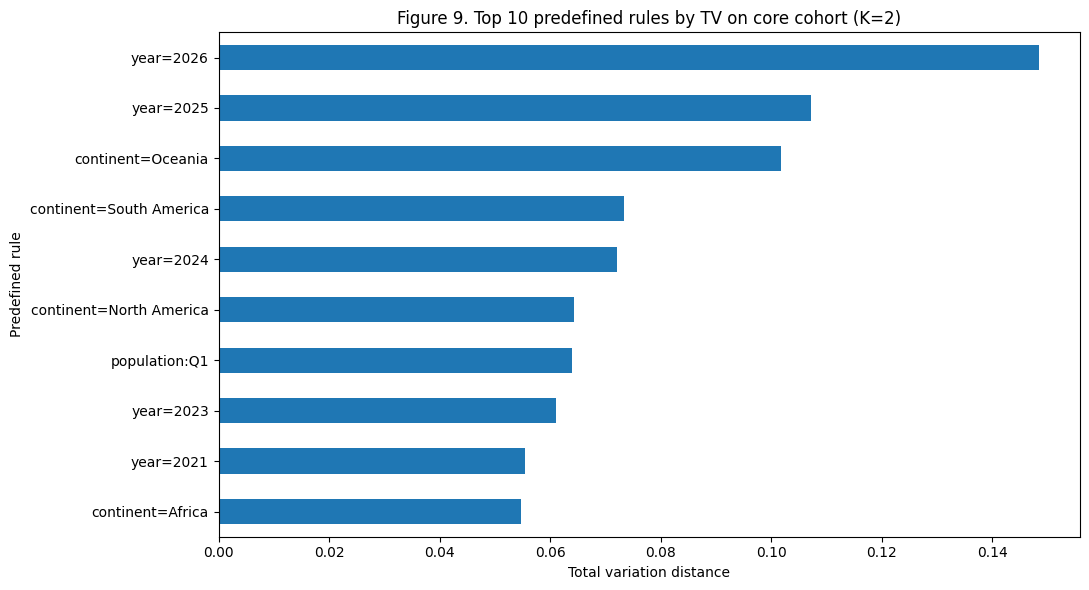

In [19]:
rule_scores, policy_summary, policy_top5=score_rules()
display(rule_scores.sort_values(['K','TV_rank']))
display(policy_summary)
display(policy_top5)
for k in (1,2):
    table=rule_scores.loc[rule_scores.K.eq(k)].sort_values('TV',ascending=False).head(10).set_index('rule')
    ax=table.TV.sort_values().plot.barh(figsize=(11,6))
    ax.set_title(f'Figure {k+7}. Top 10 predefined rules by TV on core cohort (K={k})')
    ax.set_xlabel('Total variation distance'); ax.set_ylabel('Predefined rule')
    plt.tight_layout(); plt.savefig(FIG/f'figure_{k+7}_prepared_rules_tv_k{k}.png',dpi=150); plt.show()


## 12. Tables 16–17 and Figure 10: Country weighting and year coverage

Equal-week weighting lets countries with more weeks contribute more. Country-equal weighting averages each country's normalized digit distribution separately inside subgroup and complement. This changes the estimand, rather than automatically correcting it. Inspect year-specific locations and dates; 2026 is incomplete. Neither comparison establishes significance.

In [20]:
"""Descriptive sensitivity to unequal country contribution and year coverage."""
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import json
import pandas as pd
from scripts.run_pre_emm_experiment import distribution
from scripts.compare_quality_measures import distances

ROOT=Path.cwd()
OUT=ROOT/'data/processed/pre_emm_2026-10-05'

def country_equal_distribution(d,field,k):
    # Normalize within each country, then average countries equally within group.
    probabilities=[distribution(g[field],k) for _,g in d.groupby('country')]
    if not probabilities: raise ValueError('Empty group')
    return pd.concat(probabilities,axis=1).mean(axis=1)

def audit_sensitivity():
    started=datetime.now(ZoneInfo('Europe/Berlin')).isoformat()
    scores=[]; coverage=[]
    for k,field in [(1,'first_digit'),(2,'first_2_digits')]:
        d=pd.read_csv(OUT/f'cohort_k{k}_core_binned.csv',dtype={field:'string'},parse_dates=['week_start','week_end'])
        for year,g in d.groupby('year'):
            coverage.append({'K':k,'year':int(year),'weeks':len(g),'locations':g.country.nunique(),
                'first_week_start':g.week_start.min(),'last_week_end':g.week_end.max(),
                'median_weeks_per_location':g.groupby('country').size().median(),
                'max_country_share':g.groupby('country').size().max()/len(g)})
        rules={f'continent={v}':d.continent.eq(v) for v in sorted(d.continent.unique())}
        rules.update({f'year={v}':d.year.eq(v) for v in sorted(d.year.unique())})
        for c in ['population','median_age','life_expectancy','population_density']:
            rules.update({f'{c}:{v}':d[c+'_bin'].eq(v) for v in ['Q1','Q2','Q3','Q4']})
        for name,mask in rules.items():
            for weighting in ('week_equal','country_equal'):
                group=d.loc[mask]; complement=d.loc[~mask]
                if weighting=='week_equal':
                    p,q=distribution(group[field],k),distribution(complement[field],k)
                else:
                    p,q=country_equal_distribution(group,field,k),country_equal_distribution(complement,field,k)
                scores.append({'K':k,'rule':name,'weighting':weighting,
                    'subgroup_locations':group.country.nunique(),'complement_locations':complement.country.nunique(),**distances(p,q)})
    result=pd.DataFrame(scores)
    for measure in ['TV','JS_divergence_bits','Hellinger']:
        result[measure+'_rank']=result.groupby(['K','weighting'])[measure].rank(method='min',ascending=False).astype(int)
    result.to_csv(OUT/'country_weighting_scores.csv',index=False)
    years=pd.DataFrame(coverage)
    years.to_csv(OUT/'year_coverage_audit.csv',index=False)
    # Removing year=2026 from the ranking is only a candidate-rule check, not
    # a rerun on a restricted dataset. Record that distinction explicitly.
    no_latest=result.loc[~result.rule.eq('year=2026')].copy()
    no_latest['TV_rank_without_2026_rule']=no_latest.groupby(['K','weighting']).TV.rank(method='min',ascending=False).astype(int)
    no_latest.to_csv(OUT/'ranking_without_2026_rule.csv',index=False)
    meta={'started_at':started,'finished_at':datetime.now(ZoneInfo('Europe/Berlin')).isoformat(),
        'country_equal_definition':'Each country gets equal weight separately inside subgroup and complement after its digit distribution is normalized.',
        'interpretation':'Different estimand from equal-week distribution; comparison is descriptive, not significance testing.',
        'latest_year_check':'Coverage table plus removing 2026 candidate rule; latter does not remove 2026 records from other groups.',
        'remaining':'A common reporting window and dependence-aware uncertainty remain research design choices.'}
    (OUT/'weighting_sensitivity_metadata.json').write_text(json.dumps(meta,indent=2),encoding='utf-8')
    print(json.dumps(meta,indent=2))
    return result,years

if __name__=='__main__': audit_sensitivity()


{
  "started_at": "2026-10-05T20:06:24.696619+02:00",
  "finished_at": "2026-10-05T20:06:47.246149+02:00",
  "country_equal_definition": "Each country gets equal weight separately inside subgroup and complement after its digit distribution is normalized.",
  "interpretation": "Different estimand from equal-week distribution; comparison is descriptive, not significance testing.",
  "latest_year_check": "Coverage table plus removing 2026 candidate rule; latter does not remove 2026 records from other groups.",
  "remaining": "A common reporting window and dependence-aware uncertainty remain research design choices."
}


{
  "started_at": "2026-10-05T20:06:47.256928+02:00",
  "finished_at": "2026-10-05T20:07:09.977086+02:00",
  "country_equal_definition": "Each country gets equal weight separately inside subgroup and complement after its digit distribution is normalized.",
  "interpretation": "Different estimand from equal-week distribution; comparison is descriptive, not significance testing.",
  "latest_year_check": "Coverage table plus removing 2026 candidate rule; latter does not remove 2026 records from other groups.",
  "remaining": "A common reporting window and dependence-aware uncertainty remain research design choices."
}


,K,year,weeks,locations,first_week_start,last_week_end,median_weeks_per_location,max_country_share
0,1,2020,8249,214,2020-01-06,2021-01-03,43.0,0.006304
1,1,2021,10493,216,2021-01-04,2022-01-02,52.0,0.004956
2,1,2022,10373,225,2022-01-03,2023-01-01,51.0,0.005013
3,1,2023,6263,206,2023-01-02,2023-12-31,30.0,0.008303
4,1,2024,4409,141,2024-01-01,2025-01-05,31.0,0.012021
5,1,2025,3300,107,2025-01-06,2026-01-04,31.0,0.015758
6,1,2026,1480,82,2026-01-05,2026-08-30,14.0,0.022973
7,2,2020,6963,200,2020-01-06,2021-01-03,40.0,0.007468
8,2,2021,9944,208,2021-01-04,2022-01-02,52.0,0.005229
9,2,2022,9719,224,2022-01-03,2023-01-01,51.0,0.005350


,K,rule,weighting,subgroup_locations,complement_locations,TV,JS_divergence_bits,Hellinger,TV_rank,JS_divergence_bits_rank,Hellinger_rank
25,1,year=2026,country_equal,82,226,0.119621,0.015650,0.104470,1,1,1
23,1,year=2025,country_equal,107,226,0.092557,0.007997,0.074510,2,2,2
21,1,year=2024,country_equal,141,226,0.057010,0.002641,0.042796,3,3,3
11,1,continent=South America,country_equal,14,212,0.038351,0.001483,0.032069,4,4,4
9,1,continent=Oceania,country_equal,23,203,0.032892,0.001308,0.030117,5,5,5
24,1,year=2026,week_equal,82,226,0.057400,0.004424,0.055430,1,1,1
22,1,year=2025,week_equal,107,226,0.050066,0.002072,0.037908,2,2,2
14,1,year=2021,week_equal,216,226,0.034470,0.000974,0.025981,3,4,4
10,1,continent=South America,week_equal,14,212,0.030838,0.000884,0.024756,4,5,5
6,1,continent=North America,week_equal,40,186,0.028577,0.000992,0.026234,5,3,3


weighting                  country_equal  week_equal
K rule                                              
1 continent=Africa                    10           7
  continent=Asia                      24          14
  continent=Europe                    25          27
  continent=North America              9           5
  continent=Oceania                    5          12
  continent=South America              4           4
  life_expectancy:Q1                  23           8
  life_expectancy:Q2                  28          28
  life_expectancy:Q3                  17          23
  life_expectancy:Q4                  18          19
  median_age:Q1                       15           9
  median_age:Q2                        7          10
  median_age:Q3                       29          29
  median_age:Q4                       27          26
  population:Q1                       11          15
  population:Q2                       22          20
  population:Q3                       16          13
  population:Q4                       14          17
  population_density:Q1               21          21
  population_density:Q2               20          24
  population_density:Q3               13          25
  population_density:Q4               19          22
  year=2020                           26          18
  year=2021                            6           3
  year=2022                            8          11
  year=2023                           12          16
  year=2024                            3           6
  year=2025                            2           2
  year=2026                            1           1
2 continent=Africa                    17          10
  continent=Asia                      26          18
  continent=Europe                    13          24
  continent=North America              9           6
  continent=Oceania                    4           3
  continent=South America              6           4
  life_expectancy:Q1                   8          11
  life_expectancy:Q2                  10          17
  life_expectancy:Q3                  22          28
  life_expectancy:Q4                  16          25
  median_age:Q1                       21          14
  median_age:Q2                       29          26
  median_age:Q3                       19          16
  median_age:Q4                       15          20
  population:Q1                        7           7
  population:Q2                       25          22
  population:Q3                       23          19
  population:Q4                       28          27
  population_density:Q1               18          21
  population_density:Q2               20          29
  population_density:Q3               24          23
  population_density:Q4               12          15
  year=2020                           14          12
  year=2021                           11           9
  year=2022                           27          13
  year=2023                            5           8
  year=2024                            3           5
  year=2025                            2           2
  year=2026                            1           1

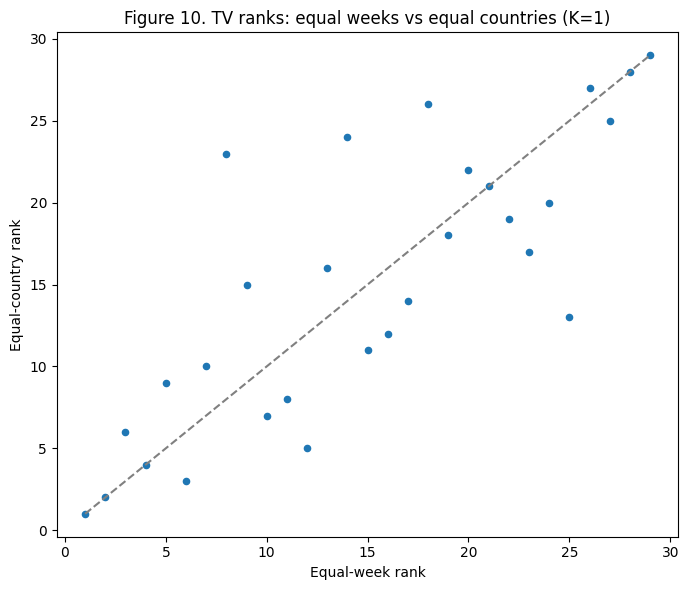

In [21]:
weight_scores, year_coverage=audit_sensitivity()
display(year_coverage)
display(weight_scores.sort_values(['K','weighting','TV_rank']).groupby(['K','weighting']).head(5))
rank_compare=weight_scores.pivot(index=['K','rule'],columns='weighting',values='TV_rank')
display(rank_compare)
ax=rank_compare.loc[1].plot.scatter(x='week_equal',y='country_equal',figsize=(7,6))
ax.plot([1,29],[1,29],linestyle='--',color='gray')
ax.set_title('Figure 10. TV ranks: equal weeks vs equal countries (K=1)')
ax.set_xlabel('Equal-week rank'); ax.set_ylabel('Equal-country rank')
plt.tight_layout(); plt.savefig(FIG/'figure_10_country_weight_rank_comparison.png',dpi=150); plt.show()


## 13. Status and next work

Completed daily-to-week validation, coverage audits, model checks, fixed cohorts, bins, predefined rule scores, support sensitivity, country-equal weighting and year coverage. Remaining research choices include a common reporting window, dependence-aware uncertainty, minimum support sensitivity for combinations and interpretation. EMM integration requires the exact Lucas repository and interface. No automatic EMM results or fraud claims are presented.

Results: local `F:/TUeclass/projects/track3_owid/data/processed/pre_emm_2026-10-05/`; JupyterLab `data → processed → pre_emm_2026-10-05`. Figures: `figures → pre_emm_2026-10-05`. Log: `docs → decisions → operation_log.md`.